In [ ]:
import urllib.request
import pandas as pd

# songys 한국어 챗봇 데이터 (Q-A 쌍)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv",
    filename="ChatbotData.csv"
)

df = pd.read_csv("ChatbotData.csv")
print("총 샘플 수:", len(df))
print("컬럼:", list(df.columns))
print("결측치:\n", df.isnull().sum())
print("\nlabel 분포:\n", df['label'].value_counts())
df.head()

총 샘플 수: 11823
컬럼: ['Q', 'A', 'label']
결측치:
 Q        0
A        0
label    0
dtype: int64

label 분포:
 label
0    5290
1    3570
2    2963
Name: count, dtype: int64


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [ ]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.strip()
    # 구두점 앞뒤로 공백 분리 (예: "12시 땡!" -> "12시 땡 !")
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 한글, 영어, 숫자, 지정 구두점 외 문자 제거
    sentence = re.sub(r"[^ ?.!,A-Za-z0-9가-힣]", "", sentence)
    # 중복 공백 정리
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()

# 정제 적용
questions = [preprocess_sentence(q) for q in df['Q']]
answers   = [preprocess_sentence(a) for a in df['A']]

# 확인
for i in range(5):
    print(f"Q: {questions[i]}")
    print(f"A: {answers[i]}\n")

Q: 12시 땡 !
A: 하루가 또 가네요 .

Q: 1지망 학교 떨어졌어
A: 위로해 드립니다 .

Q: 3박4일 놀러가고 싶다
A: 여행은 언제나 좋죠 .

Q: 3박4일 정도 놀러가고 싶다
A: 여행은 언제나 좋죠 .

Q: PPL 심하네
A: 눈살이 찌푸려지죠 .



In [ ]:
import random
random.seed(42)

# ── 조사/어미 변형 규칙 (문장 끝 위주, 안전한 것만) ──
ENDING_RULES = [
    ("볼래", "볼까"), ("할래", "할까"), ("갈래", "갈까"),
    ("먹을래", "먹을까"), ("있어", "있어요"), ("없어", "없어요"),
    ("좋아", "좋아요"), ("어때", "어떨까"), ("니", "나요"),
]

def aug_random_deletion(words, p=0.15):
    """단어를 확률 p로 삭제 (최소 1개는 남김)"""
    if len(words) <= 2:
        return words
    kept = [w for w in words if random.random() > p]
    return kept if kept else [random.choice(words)]

def aug_random_swap(words, n=1):
    """인접 아닌 두 단어 위치를 n번 교체"""
    words = words[:]
    if len(words) < 2:
        return words
    for _ in range(n):
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return words

def aug_ending(sentence):
    """어미/조사 규칙 치환 (해당되는 게 있으면 1개 적용)"""
    random.shuffle(ENDING_RULES)
    for a, b in ENDING_RULES:
        if a in sentence:
            return sentence.replace(a, b, 1)
    return None  # 해당 규칙 없음

def augment_question(q):
    """질문 하나에서 변형 후보들을 만든다 (중복·원본 제외)"""
    variants = set()
    words = q.split()

    # RD
    variants.add(" ".join(aug_random_deletion(words)))
    # RS
    variants.add(" ".join(aug_random_swap(words)))
    # 어미 변형
    e = aug_ending(q)
    if e:
        variants.add(e)

    variants.discard(q)          # 원본과 같은 건 제외
    variants.discard("")         # 빈 문장 제외
    return list(variants)

# 테스트
test_q = "영화 볼래 ?"
print("원본:", test_q)
print("변형:", augment_question(test_q))

원본: 영화 볼래 ?
변형: ['영화 ?', '영화 볼까 ?', '? 볼래 영화']


In [ ]:
from collections import Counter

aug_questions = []
aug_answers = []

# 원본 먼저 모두 포함
for q, a in zip(questions, answers):
    aug_questions.append(q)
    aug_answers.append(a)

# 증강: 각 질문에서 변형을 만들어 같은 답변에 매핑
TARGET = 30000
random.seed(42)

# 순서를 섞어서 골고루 증강되게
idx = list(range(len(questions)))
random.shuffle(idx)

for i in idx:
    if len(aug_questions) >= TARGET:
        break
    variants = augment_question(questions[i])
    for v in variants:
        if len(aug_questions) >= TARGET:
            break
        aug_questions.append(v)
        aug_answers.append(answers[i])   # A는 원본 유지

print(f"원본: {len(questions)}쌍")
print(f"증강 후: {len(aug_questions)}쌍")

# 검증 1: 중복 (Q,A) 쌍 확인
pairs = list(zip(aug_questions, aug_answers))
dup = len(pairs) - len(set(pairs))
print(f"완전 중복 쌍: {dup}개")

# 검증 2: 빈 질문 확인
empty = sum(1 for q in aug_questions if len(q.strip()) == 0)
print(f"빈 질문: {empty}개")

# 검증 3: 답변 분포 보존 확인 (원본 A가 골고루 남았는지)
print(f"고유 답변 수: {len(set(aug_answers))}")

원본: 11823쌍
증강 후: 29629쌍
완전 중복 쌍: 135개
빈 질문: 0개
고유 답변 수: 7779


In [ ]:
import pandas as pd

# (Q, A) 완전 중복 제거
aug_df = pd.DataFrame({'Q': aug_questions, 'A': aug_answers})
before = len(aug_df)
aug_df = aug_df.drop_duplicates(subset=['Q', 'A']).reset_index(drop=True)
after = len(aug_df)

print(f"중복 제거: {before} -> {after} ({before-after}개 제거)")

# 최종 리스트 갱신
aug_questions = aug_df['Q'].tolist()
aug_answers   = aug_df['A'].tolist()

# 최종 검증
print(f"\n최종 증강 데이터: {len(aug_df)}쌍")
print(f"원본 대비 배율: {len(aug_df)/len(questions):.2f}배")

# 샘플 확인 (같은 답변에 여러 질문이 매핑됐는지)
sample_a = aug_df['A'].value_counts().index[0]
print(f"\n'{sample_a}' 답변에 매핑된 질문들 (일부):")
print(aug_df[aug_df['A'] == sample_a]['Q'].head(6).tolist())

중복 제거: 29629 -> 29494 (135개 제거)

최종 증강 데이터: 29494쌍
원본 대비 배율: 2.49배

'맛있게 드세요 .' 답변에 매핑된 질문들 (일부):
['간장치킨 시켜야지', '감 말랭이 먹고 싶다 .', '감 말랭이 먹어야지', '도시락 싸가지고 가야지', '도시락 싸봐야지', '도시락 싸옴']


In [ ]:
import sentencepiece as spm
import os

# 토크나이저 학습용 코퍼스 저장 (Q, A 모두 합쳐서 하나의 vocab)
os.makedirs("tokenizer", exist_ok=True)
with open("tokenizer/corpus.txt", "w", encoding="utf-8") as f:
    for s in aug_questions + aug_answers:
        f.write(s + "\n")

# SentencePiece 학습
VOCAB_SIZE = 8000
spm.SentencePieceTrainer.Train(
    input="tokenizer/corpus.txt",
    model_prefix="tokenizer/chatbot_spm",
    vocab_size=VOCAB_SIZE,
    model_type="bpe",
    pad_id=0, pad_piece="<pad>",
    bos_id=1, bos_piece="<bos>",
    eos_id=2, eos_piece="<eos>",
    unk_id=3, unk_piece="<unk>",
    user_defined_symbols=[]
)

# 로드
sp = spm.SentencePieceProcessor()
sp.Load("tokenizer/chatbot_spm.model")

print("vocab size:", sp.GetPieceSize())
# 테스트
test = "영화 볼까 ?"
print(f"\n원문: {test}")
print("토큰:", sp.EncodeAsPieces(test))
print("ID:", sp.EncodeAsIds(test))
print("복원:", sp.DecodePieces(sp.EncodeAsPieces(test)))

vocab size: 8000

원문: 영화 볼까 ?
토큰: ['▁영화', '▁볼까', '▁?']
ID: [687, 1696, 9]
복원: 영화 볼까 ?


/tmp/ipykernel_454/452494805.py:30: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/452494805.py:30: UserWarning: Glyph 53360 (\N{HANGUL SYLLABLE KEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/452494805.py:30: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/452494805.py:30: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/452494805.py:30: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/452494805.py:30: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/452494805.py:30: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

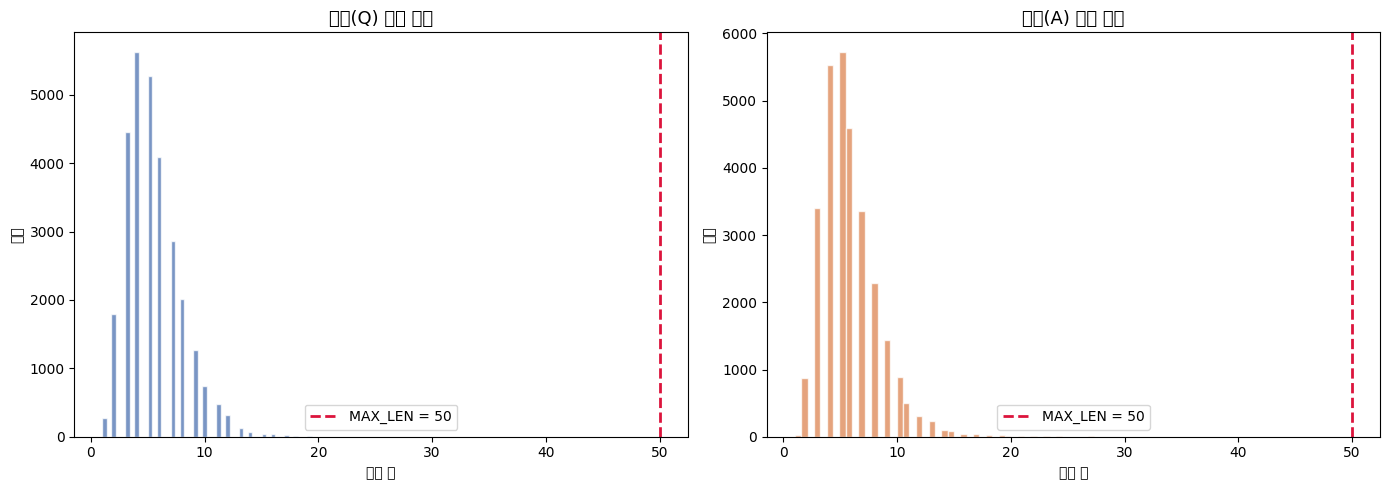

Q 길이 — 평균 5.4, 최대 21, 50 초과 0개
A 길이 — 평균 5.8, 최대 29, 50 초과 0개
둘 중 하나라도 50 초과: 0개


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 (Colab)
import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum > /dev/null
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 각 문장의 토큰 길이 계산
q_lens = [len(sp.EncodeAsIds(q)) for q in aug_questions]
a_lens = [len(sp.EncodeAsIds(a)) for a in aug_answers]

MAX_LEN = 50

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lens, title, color in [
    (axes[0], q_lens, "질문(Q) 토큰 길이", "#4C72B0"),
    (axes[1], a_lens, "답변(A) 토큰 길이", "#DD8452"),
]:
    ax.hist(lens, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(MAX_LEN, color='crimson', linestyle='--', linewidth=2,
               label=f'MAX_LEN = {MAX_LEN}')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("토큰 수"); ax.set_ylabel("빈도")
    ax.legend()

plt.tight_layout()
plt.show()

# ── 통계 요약 ──
q_over = sum(1 for l in q_lens if l > MAX_LEN)
a_over = sum(1 for l in a_lens if l > MAX_LEN)
print(f"Q 길이 — 평균 {np.mean(q_lens):.1f}, 최대 {max(q_lens)}, 50 초과 {q_over}개")
print(f"A 길이 — 평균 {np.mean(a_lens):.1f}, 최대 {max(a_lens)}, 50 초과 {a_over}개")
print(f"둘 중 하나라도 50 초과: {sum(1 for lq, la in zip(q_lens, a_lens) if lq > MAX_LEN or la > MAX_LEN)}개")

데이터 최대는 29, 50 초과되는건 없으나 기준을 위해 유지

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

MAX_LEN = 50
PAD, BOS, EOS = 0, 1, 2

# ── 길이 50 이하만 선별 (여기선 전부 통과하지만 안전장치로 명시) ──
pairs = []
for q, a in zip(aug_questions, aug_answers):
    q_ids = sp.EncodeAsIds(q)
    a_ids = sp.EncodeAsIds(a)
    if len(q_ids) <= MAX_LEN and len(a_ids) <= MAX_LEN:
        pairs.append((q_ids, a_ids))

print(f"선별 후: {len(pairs)}쌍 (MAX_LEN={MAX_LEN} 이하)")

# ── train/valid 분리 (과적합 판단용 valid 확보) ──
train_pairs, valid_pairs = train_test_split(
    pairs, test_size=0.1, random_state=42
)
print(f"train: {len(train_pairs)}, valid: {len(valid_pairs)}")

# ── Dataset 정의 ──
class ChatDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        q_ids, a_ids = self.pairs[idx]
        # 디코더 입력: <bos> ... / 디코더 타깃: ... <eos>
        enc_in  = q_ids
        dec_in  = [BOS] + a_ids
        dec_out = a_ids + [EOS]
        return (torch.tensor(enc_in), torch.tensor(dec_in), torch.tensor(dec_out))

# ── 배치별 동적 패딩 (낭비 없음) ──
def collate_fn(batch):
    enc, din, dout = zip(*batch)
    def pad(seqs):
        m = max(len(s) for s in seqs)
        return torch.stack([
            torch.cat([s, torch.full((m-len(s),), PAD)]) for s in seqs
        ])
    return pad(enc), pad(din), pad(dout)

train_ds = ChatDataset(train_pairs)
valid_ds = ChatDataset(valid_pairs)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False, collate_fn=collate_fn)

# 배치 하나 확인
enc, din, dout = next(iter(train_loader))
print(f"\n배치 shape — enc: {enc.shape}, dec_in: {din.shape}, dec_out: {dout.shape}")

선별 후: 29494쌍 (MAX_LEN=50 이하)
train: 26544, valid: 2950

배치 shape — enc: torch.Size([64, 13]), dec_in: torch.Size([64, 15]), dec_out: torch.Size([64, 15])


In [ ]:
# 모델 클래스가 세션에 정의돼 있는지 확인
import inspect
for name in ['Transformer', 'MultiHeadAttention', 'Encoder', 'Decoder']:
    if name in dir():
        print(f"✓ {name} 정의됨")
        if name == 'Transformer':
            print(inspect.signature(globals()[name].__init__))
    else:
        print(f"✗ {name} 없음")

✗ Transformer 없음
✗ MultiHeadAttention 없음
✗ Encoder 없음
✗ Decoder 없음


In [ ]:
import torch
import torch.nn as nn
import numpy as np

# ── Positional Encoding ──
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])
    return torch.tensor(pe, dtype=torch.float32)

# ── Multi-Head Attention ──
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model, self.num_heads = d_model, num_heads
        self.depth = d_model // num_heads
        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x, B):
        x = x.view(B, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)  # (B, heads, len, depth)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q, k, v = self.wq(q), self.wk(k), self.wv(v)
        q, k, v = self.split_heads(q, B), self.split_heads(k, B), self.split_heads(v, B)
        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.depth)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = self.dropout(torch.softmax(scores, dim=-1))
        ctx = torch.matmul(attn, v)                       # (B, heads, len, depth)
        ctx = ctx.permute(0, 2, 1, 3).contiguous().view(B, -1, self.d_model)
        return self.out(ctx), attn

# ── Position-wise Feed-Forward ──
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.fc2(self.dropout(torch.relu(self.fc1(x))))

print("3-1 완료: PE, MHA, FFN 정의됨")

3-1 완료: PE, MHA, FFN 정의됨


In [ ]:
# ── Encoder Layer: (self-attn → FFN), 각 뒤에 잔차연결+LayerNorm ──
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask):
        attn, _ = self.mha(x, x, x, mask)
        x = self.ln1(x + self.drop(attn))
        ffn = self.ffn(x)
        x = self.ln2(x + self.drop(ffn))
        return x

# ── Decoder Layer: (masked self-attn → enc-dec attn → FFN) ──
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_mha = MultiHeadAttention(d_model, num_heads, dropout)
        self.enc_mha  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, enc_out, look_ahead_mask, pad_mask):
        attn1, self_w = self.self_mha(x, x, x, look_ahead_mask)
        x = self.ln1(x + self.drop(attn1))
        attn2, enc_w = self.enc_mha(x, enc_out, enc_out, pad_mask)
        x = self.ln2(x + self.drop(attn2))
        ffn = self.ffn(x)
        x = self.ln3(x + self.drop(ffn))
        return x, enc_w

# ── Encoder / Decoder (임베딩 + PE + N개 레이어) ──
class Encoder(nn.Module):
    def __init__(self, vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab, d_model)
        self.register_buffer('pe', positional_encoding(max_len, d_model))
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.drop = nn.Dropout(dropout)
    def forward(self, x, mask):
        L = x.size(1)
        h = self.embed(x) * np.sqrt(self.d_model) + self.pe[:L]
        h = self.drop(h)
        for layer in self.layers:
            h = layer(h, mask)
        return h

class Decoder(nn.Module):
    def __init__(self, vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embed = nn.Embedding(vocab, d_model)
        self.register_buffer('pe', positional_encoding(max_len, d_model))
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.drop = nn.Dropout(dropout)
    def forward(self, x, enc_out, look_ahead_mask, pad_mask):
        L = x.size(1)
        h = self.embed(x) * np.sqrt(self.d_model) + self.pe[:L]
        h = self.drop(h)
        attn_weights = None
        for layer in self.layers:
            h, attn_weights = layer(h, enc_out, look_ahead_mask, pad_mask)
        return h, attn_weights

print("3-2 완료: Encoder/Decoder Layer + Encoder/Decoder 정의됨")

3-2 완료: Encoder/Decoder Layer + Encoder/Decoder 정의됨


In [ ]:
# ── 마스킹 함수 ──
def create_padding_mask(seq, pad=0):
    # seq: (B, len) → (B, 1, 1, len)  PAD 위치를 0으로
    mask = (seq != pad).unsqueeze(1).unsqueeze(2).float()
    return mask

def create_look_ahead_mask(size):
    # (size, size) 하삼각행렬: 미래 토큰 못 보게
    return torch.tril(torch.ones(size, size))

# ── Transformer 완성 ──
class Transformer(nn.Module):
    def __init__(self, vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc = nn.Linear(d_model, vocab)

    def forward(self, enc_in, dec_in):
        device = enc_in.device
        enc_pad_mask = create_padding_mask(enc_in)                 # 인코더 self-attn용
        dec_pad_mask = create_padding_mask(enc_in)                 # enc-dec attn용 (인코더 길이 기준)

        # 디코더 self-attn: look-ahead + dec_in의 PAD 둘 다 반영
        L = dec_in.size(1)
        look_ahead = create_look_ahead_mask(L).to(device)
        dec_target_pad = create_padding_mask(dec_in)               # (B,1,1,L)
        look_ahead_mask = torch.minimum(look_ahead, dec_target_pad)

        enc_out = self.encoder(enc_in, enc_pad_mask)
        dec_out, attn = self.decoder(dec_in, enc_out, look_ahead_mask, dec_pad_mask)
        return self.fc(dec_out), attn

# ── CFG 정의: A(원본) / B(축소) ──
class CFG_A:  # 논문 원본 스펙 (과적합 유도)
    d_model=512; num_layers=6; num_heads=8; d_ff=2048; dropout=0.1
class CFG_B:  # 축소 스펙 (과적합 억제)
    d_model=256; num_layers=2; num_heads=8; d_ff=512;  dropout=0.3

VOCAB = sp.GetPieceSize()   # 8000
MAX_LEN = 50

# 생성 테스트 (축소 스펙으로 파라미터 수 확인)
def build(cfg):
    return Transformer(VOCAB, cfg.d_model, cfg.num_layers,
                       cfg.num_heads, cfg.d_ff, MAX_LEN, cfg.dropout)

for name, cfg in [("A(원본)", CFG_A), ("B(축소)", CFG_B)]:
    m = build(cfg)
    n_param = sum(p.numel() for p in m.parameters())
    print(f"{name}: {n_param:,} 파라미터")
del m

print("\n3-3 완료: Transformer + 마스킹 정의됨")

A(원본): 56,434,496 파라미터
B(축소): 8,787,776 파라미터

3-3 완료: Transformer + 마스킹 정의됨


In [ ]:
import torch.nn.functional as F
import math, time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", device)

# ── 논문의 Learning Rate Scheduler (warmup) ──
class TransformerLRScheduler:
    def __init__(self, optimizer, d_model, warmup=4000):
        self.opt = optimizer; self.d_model = d_model
        self.warmup = warmup; self.step_num = 0
    def step(self):
        self.step_num += 1
        s = self.step_num
        lr = (self.d_model ** -0.5) * min(s ** -0.5, s * self.warmup ** -1.5)
        for p in self.opt.param_groups:
            p['lr'] = lr
        return lr

# ── 손실: PAD 무시 + label smoothing ──
def compute_loss(logits, target, pad=0, smoothing=0.1):
    # logits: (B, L, V), target: (B, L)
    V = logits.size(-1)
    logits = logits.view(-1, V)
    target = target.view(-1)
    loss = F.cross_entropy(logits, target, ignore_index=pad,
                           label_smoothing=smoothing)
    return loss

# ── 1 epoch 학습 ──
def train_epoch(model, loader, optimizer, scheduler):
    model.train(); total = 0
    for enc, din, dout in loader:
        enc, din, dout = enc.to(device), din.to(device), dout.to(device)
        optimizer.zero_grad()
        logits, _ = model(enc, din)
        loss = compute_loss(logits, dout)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 발산 방지
        optimizer.step(); scheduler.step()
        total += loss.item()
    return total / len(loader)

# ── 검증 (grad 없음) ──
@torch.no_grad()
def eval_epoch(model, loader):
    model.eval(); total = 0
    for enc, din, dout in loader:
        enc, din, dout = enc.to(device), din.to(device), dout.to(device)
        logits, _ = model(enc, din)
        total += compute_loss(logits, dout).item()
    return total / len(loader)

print("4-1 완료: 스케줄러 + 학습/검증 함수 정의됨")

device: cuda
4-1 완료: 스케줄러 + 학습/검증 함수 정의됨


In [ ]:
def run_experiment(cfg, name, epochs=20, warmup=4000):
    torch.manual_seed(42)  # 공정 비교: 동일 seed
    model = build(cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)
    scheduler = TransformerLRScheduler(optimizer, cfg.d_model, warmup)

    history = {'train': [], 'valid': []}
    print(f"\n{'='*45}\n[{name}] 학습 시작 "
          f"(d_model={cfg.d_model}, layers={cfg.num_layers}, dropout={cfg.dropout})\n{'='*45}")
    for ep in range(1, epochs+1):
        t = time.time()
        tr = train_epoch(model, train_loader, optimizer, scheduler)
        va = eval_epoch(model, valid_loader)
        history['train'].append(tr); history['valid'].append(va)
        gap = va - tr
        flag = "  ← gap 벌어짐" if gap > 0.3 else ""
        print(f"ep {ep:2d} | train {tr:.4f} | valid {va:.4f} | gap {gap:+.4f}{flag} | {time.time()-t:.0f}s")
    return model, history

# ── 실험 A: 원본 스펙 (과적합 유도) ──
model_A, hist_A = run_experiment(CFG_A, "A(원본 512/6)", epochs=20)

# ── 실험 B: 축소 스펙 (과적합 억제) ──
model_B, hist_B = run_experiment(CFG_B, "B(축소 256/2)", epochs=20)

print("\n4-2 완료: A/B 학습 끝")


[A(원본 512/6)] 학습 시작 (d_model=512, layers=6, dropout=0.1)
ep  1 | train 6.5006 | valid 5.8822 | gap -0.6184 | 47s
ep  2 | train 5.5133 | valid 5.0420 | gap -0.4713 | 49s
ep  3 | train 4.6674 | valid 4.3089 | gap -0.3585 | 52s
ep  4 | train 3.8189 | valid 3.5433 | gap -0.2757 | 50s
ep  5 | train 2.9632 | valid 2.8184 | gap -0.1448 | 51s
ep  6 | train 2.2821 | valid 2.3092 | gap +0.0271 | 51s
ep  7 | train 1.9279 | valid 2.0386 | gap +0.1107 | 51s
ep  8 | train 1.7970 | valid 1.9609 | gap +0.1639 | 51s
ep  9 | train 1.7734 | valid 1.9365 | gap +0.1632 | 50s
ep 10 | train 1.7807 | valid 1.9255 | gap +0.1448 | 50s
ep 11 | train 1.7422 | valid 1.8814 | gap +0.1392 | 50s
ep 12 | train 1.6792 | valid 1.8134 | gap +0.1341 | 50s
ep 13 | train 1.6345 | valid 1.7763 | gap +0.1419 | 50s
ep 14 | train 1.5968 | valid 1.7467 | gap +0.1498 | 51s
ep 15 | train 1.5658 | valid 1.7421 | gap +0.1764 | 50s
ep 16 | train 1.5383 | valid 1.7075 | gap +0.1692 | 50s
ep 17 | train 1.5141 | valid 1.6942 | gap +0.1

In [ ]:
# B를 충분한 epoch로 재학습 (수렴시키기)
model_B, hist_B = run_experiment(CFG_B, "B(축소 256/2) 수렴", epochs=40)

print("\nB 재학습 완료")
print(f"최종 train {hist_B['train'][-1]:.4f} | valid {hist_B['valid'][-1]:.4f} | "
      f"gap {hist_B['valid'][-1]-hist_B['train'][-1]:+.4f}")


[B(축소 256/2) 수렴] 학습 시작 (d_model=256, layers=2, dropout=0.3)
ep  1 | train 7.0671 | valid 6.2719 | gap -0.7952 | 11s
ep  2 | train 6.1601 | valid 5.8945 | gap -0.2656 | 11s
ep  3 | train 5.8049 | valid 5.4519 | gap -0.3530 | 11s
ep  4 | train 5.3835 | valid 4.9919 | gap -0.3916 | 10s
ep  5 | train 4.9183 | valid 4.5746 | gap -0.3436 | 11s
ep  6 | train 4.4676 | valid 4.2158 | gap -0.2517 | 11s
ep  7 | train 4.0899 | valid 3.9285 | gap -0.1614 | 11s
ep  8 | train 3.8054 | valid 3.6959 | gap -0.1094 | 11s
ep  9 | train 3.5800 | valid 3.4615 | gap -0.1184 | 11s
ep 10 | train 3.4064 | valid 3.2745 | gap -0.1319 | 10s
ep 11 | train 3.2381 | valid 3.0902 | gap -0.1479 | 10s
ep 12 | train 3.0820 | valid 2.9472 | gap -0.1348 | 11s
ep 13 | train 2.9485 | valid 2.8282 | gap -0.1203 | 11s
ep 14 | train 2.8336 | valid 2.7421 | gap -0.0915 | 10s
ep 15 | train 2.7467 | valid 2.6444 | gap -0.1023 | 11s
ep 16 | train 2.6592 | valid 2.5616 | gap -0.0975 | 10s
ep 17 | train 2.5874 | valid 2.4988 | gap -

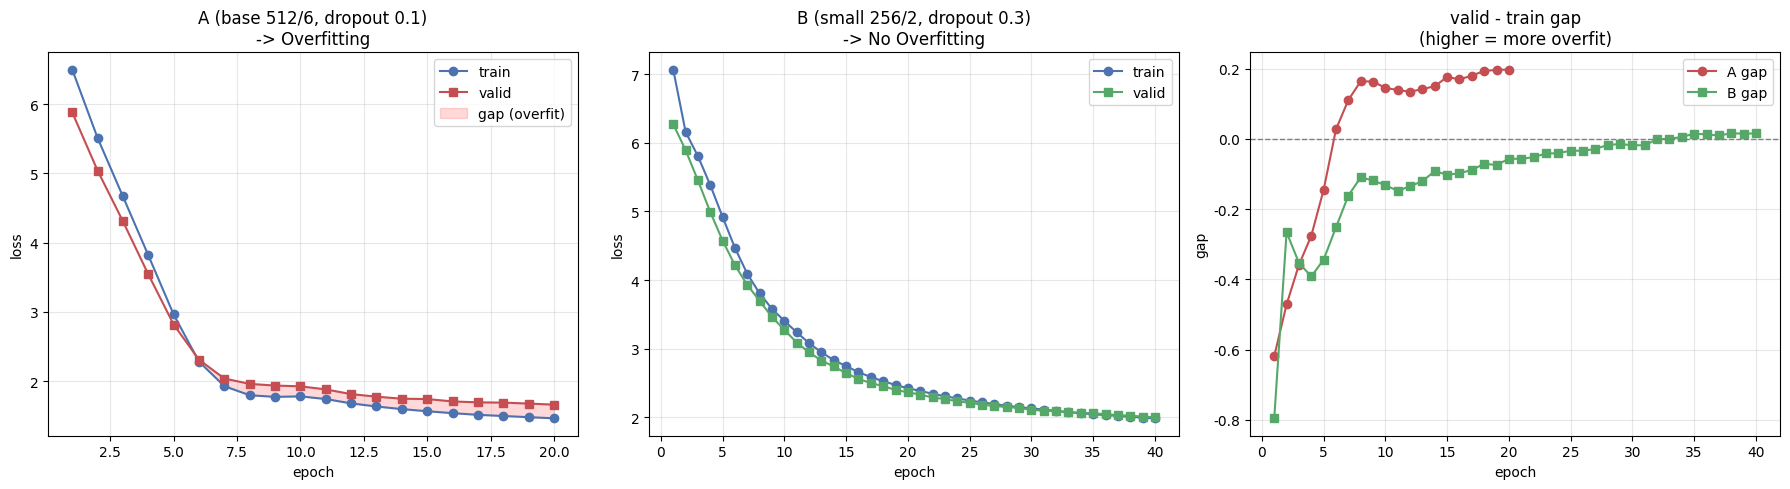

A 최종 gap: +0.1973  (과적합)
B 최종 gap: +0.0154  (건강)


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (1) A: 과적합 ──
ax = axes[0]
ep_A = range(1, len(hist_A['train'])+1)
ax.plot(ep_A, hist_A['train'], 'o-', label='train', color='#4C72B0')
ax.plot(ep_A, hist_A['valid'], 's-', label='valid', color='#C44E52')
ax.fill_between(ep_A, hist_A['train'], hist_A['valid'],
                where=[v>t for t,v in zip(hist_A['train'],hist_A['valid'])],
                color='red', alpha=0.15, label='gap (overfit)')   # 과적합 영역 음영
ax.set_title('A (base 512/6, dropout 0.1)\n-> Overfitting', fontsize=12)
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.legend(); ax.grid(alpha=0.3)

# ── (2) B: 건강 (과적합 없음) ──
ax = axes[1]
ep_B = range(1, len(hist_B['train'])+1)
ax.plot(ep_B, hist_B['train'], 'o-', label='train', color='#4C72B0')
ax.plot(ep_B, hist_B['valid'], 's-', label='valid', color='#55A868')
ax.set_title('B (small 256/2, dropout 0.3)\n-> No Overfitting', fontsize=12)
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.legend(); ax.grid(alpha=0.3)

# ── (3) gap 직접 비교 (이 실험의 핵심 한 장) ──
ax = axes[2]
gap_A = [v-t for t,v in zip(hist_A['train'], hist_A['valid'])]   # A의 valid-train
gap_B = [v-t for t,v in zip(hist_B['train'], hist_B['valid'])]   # B의 valid-train
ax.plot(ep_A, gap_A, 'o-', label='A gap', color='#C44E52')
ax.plot(ep_B, gap_B, 's-', label='B gap', color='#55A868')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('valid - train gap\n(higher = more overfit)', fontsize=12)
ax.set_xlabel('epoch'); ax.set_ylabel('gap'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"A 최종 gap: {gap_A[-1]:+.4f}  (과적합)")   # 출력 텍스트도 한글 유지
print(f"B 최종 gap: {gap_B[-1]:+.4f}  (건강)")

In [ ]:
@torch.no_grad()
def generate_reply(model, question, max_len=50):
    model.eval()
    # 질문 전처리 (학습 때와 동일하게)
    q = preprocess_sentence(question)
    enc_in = torch.tensor([sp.EncodeAsIds(q)]).to(device)

    # 디코더: <bos>부터 한 토큰씩 생성 (greedy)
    dec_in = torch.tensor([[BOS]]).to(device)
    attn_last = None
    for _ in range(max_len):
        logits, attn = model(enc_in, dec_in)
        next_id = logits[0, -1].argmax().item()   # 마지막 위치의 최고 확률 토큰
        attn_last = attn
        if next_id == EOS:
            break
        dec_in = torch.cat([dec_in, torch.tensor([[next_id]]).to(device)], dim=1)

    # <bos> 뒤부터가 답변
    reply_ids = dec_in[0, 1:].tolist()
    reply = sp.DecodeIds(reply_ids)
    return reply, enc_in, dec_in, attn_last

# 빠른 테스트
for q in ["영화 볼래?", "고민이 있어", "너무 힘들다"]:
    reply, *_ = generate_reply(model_B, q)
    print(f"Q: {q}")
    print(f"A: {reply}\n")

Q: 영화 볼래?
A: 영화보고 마음에 영화 같은 사랑해보세요 .

Q: 고민이 있어
A: 생각을 종하세요 .

Q: 너무 힘들다
A: 지금 무슨 말을 해도 와닿지 않겠지만 잘 이겨낼 거라 믿어요 .



In [ ]:
# 루브릭 지정 예문 4개 (필수)
given_examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("="*50)
print("  [필수] 주어진 예문 4개에 대한 챗봇 답변")
print("="*50)
for q in given_examples:
    reply, *_ = generate_reply(model_B, q)
    print(f"\nQ: {q}")
    print(f"A: {reply}")

# 추가 일상 사례 (다양성 보여주기)
extra_examples = [
    "안녕!", "배고파", "오늘 날씨 좋다", "시험 망쳤어",
    "사랑이 뭘까?", "주말에 뭐하지?",
]
print("\n" + "="*50)
print("  [추가] 일상 질문 사례")
print("="*50)
for q in extra_examples:
    reply, *_ = generate_reply(model_B, q)
    print(f"\nQ: {q}")
    print(f"A: {reply}")

  [필수] 주어진 예문 4개에 대한 챗봇 답변

Q: 지루하다, 놀러가고 싶어.
A: 친구들과 함께면 어디든 좋아요 .

Q: 오늘 일찍 일어났더니 피곤하다.
A: 이제 일어날 시간이에요 .

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 즐거운 데이트였길 바랍니다 .

Q: 집에 있는다는 소리야.
A: 서로에게 좋은 영향을 주는 관계입니다 .

  [추가] 일상 질문 사례

Q: 안녕!
A: 안녕 !

Q: 배고파
A: 얼른 맛난 음식 드세요 .

Q: 오늘 날씨 좋다
A: 나들이 가보세요 .

Q: 시험 망쳤어
A: 철밥통 되기가 어디 쉽겠어요 .

Q: 사랑이 뭘까?
A: 신뢰입니다 .

Q: 주말에 뭐하지?
A: 저랑 이야기해요 .


/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 52828 (\N{HANGUL SYLLABLE CIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyke

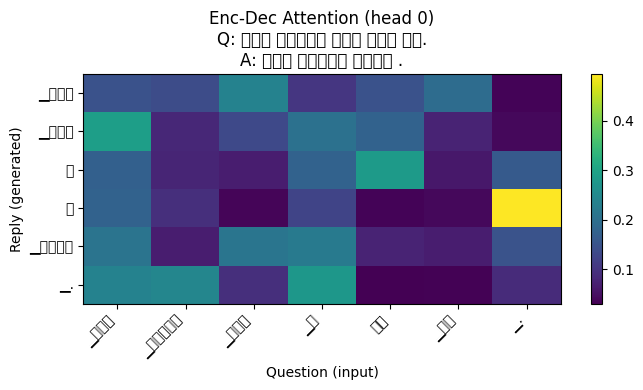

/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 50620 (\N{HANGUL SYLLABLE EOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 47579 (\N{HANGUL SYLLABLE MAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_454/983632771.py:26: UserWarning: Glyph 45212 (\N{HANGUL SYLLABLE NAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

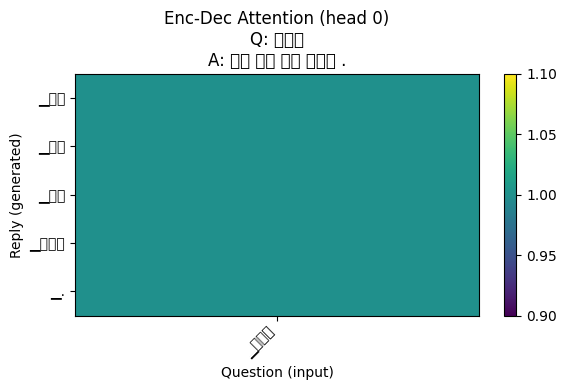

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def plot_attention(model, question, head=0):
    reply, enc_in, dec_in, attn = generate_reply(model, question)
    # attn: 디코더의 enc-dec attention (B, heads, dec_len, enc_len)
    attn_map = attn[0, head].cpu().numpy()   # (dec_len, enc_len)

    q_tokens = sp.EncodeAsPieces(preprocess_sentence(question))
    a_tokens = [sp.IdToPiece(i) for i in dec_in[0, 1:].tolist()]

    # 크기 맞추기 (생성 마지막 스텝 기준)
    attn_map = attn_map[:len(a_tokens), :len(q_tokens)]

    fig, ax = plt.subplots(figsize=(max(6, len(q_tokens)), max(4, len(a_tokens)*0.6)))
    im = ax.imshow(attn_map, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(q_tokens)))
    ax.set_yticks(range(len(a_tokens)))
    ax.set_xticklabels(q_tokens, rotation=45, ha='right')
    ax.set_yticklabels(a_tokens)
    ax.set_xlabel('Question (input)')
    ax.set_ylabel('Reply (generated)')
    ax.set_title(f'Enc-Dec Attention (head {head})\nQ: {question}\nA: {reply}')
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# 잘 답한 예문으로 시각화
plot_attention(model_B, "간만에 여자친구랑 데이트 하기로 했어.", head=0)
plot_attention(model_B, "배고파", head=0)

?
왜 색이 단색이냐

/tmp/ipykernel_454/1114408974.py:26: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_454/1114408974.py:26: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_454/1114408974.py:26: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_454/1114408974.py:26: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_454/1114408974.py:26: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_454/1114408974.py:26: UserWarning: Glyph 52828 (\N{HANGUL SYLLABLE CIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_454/1114408974.py:26: UserWarning: Glyph 44396 (\N{HANGUL 

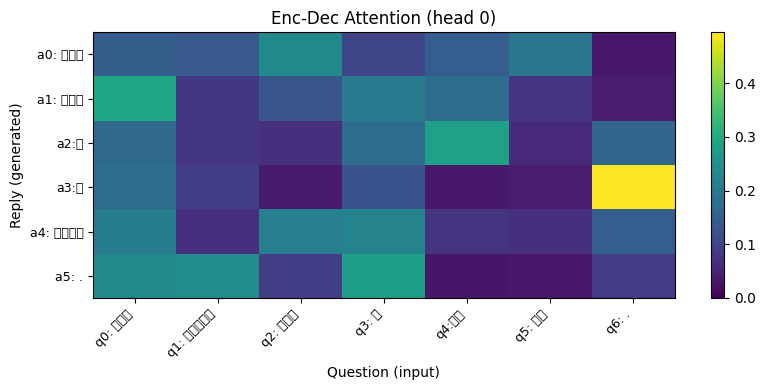

Q tokens: ['▁간만에', '▁여자친구랑', '▁데이트', '▁하', '기로', '▁했어', '▁.']
A tokens: ['▁즐거운', '▁데이트', '였', '길', '▁바랍니다', '▁.']
attn_map shape: (6, 7) | min 0.030 max 0.495
Reply: 즐거운 데이트였길 바랍니다 .


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['axes.unicode_minus'] = False

@torch.no_grad()
def plot_attention(model, question, head=0):
    reply, enc_in, dec_in, attn = generate_reply(model, question)
    attn_map = attn[0, head].cpu().numpy()          # (dec_len, enc_len)

    q_tokens = sp.EncodeAsPieces(preprocess_sentence(question))
    a_tokens = [sp.IdToPiece(i) for i in dec_in[0, 1:].tolist()]
    attn_map = attn_map[:len(a_tokens), :len(q_tokens)]

    # 라벨은 ▁만 공백으로 바꾸고, 한글 폰트 문제 피하려 로마자 인덱스 병기
    q_lab = [f"q{i}:{t.replace('▁',' ')}" for i, t in enumerate(q_tokens)]
    a_lab = [f"a{i}:{t.replace('▁',' ')}" for i, t in enumerate(a_tokens)]

    fig, ax = plt.subplots(figsize=(max(6, len(q_tokens)*1.2), max(4, len(a_tokens)*0.6)))
    im = ax.imshow(attn_map, cmap='viridis', aspect='auto', vmin=0, vmax=attn_map.max())
    ax.set_xticks(range(len(q_tokens))); ax.set_yticks(range(len(a_tokens)))
    ax.set_xticklabels(q_lab, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(a_lab, fontsize=9)
    ax.set_xlabel('Question (input)'); ax.set_ylabel('Reply (generated)')
    ax.set_title(f'Enc-Dec Attention (head {head})')
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

    # 콘솔에 한글 토큰 매핑 출력 (여긴 안 깨짐)
    print("Q tokens:", q_tokens)
    print("A tokens:", a_tokens)
    print("attn_map shape:", attn_map.shape,
          "| min", f"{attn_map.min():.3f}", "max", f"{attn_map.max():.3f}")
    return reply

# 여러 토큰 있는 질문으로 (배고파는 1토큰이라 밋밋함)
r = plot_attention(model_B, "간만에 여자친구랑 데이트 하기로 했어.", head=0)
print("Reply:", r)

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np

smooth = SmoothingFunction().method4   # 짧은 문장용 스무딩

# ── 문장 하나에 대한 BLEU  ──
def calculate_bleu(reference, hypothesis):
    """
    reference : 정답 답변 (문자열)
    hypothesis: 모델이 생성한 답변 (문자열)
    반환      : BLEU score (0~1)
    """
    ref_tokens = sp.EncodeAsPieces(preprocess_sentence(reference))
    hyp_tokens = sp.EncodeAsPieces(preprocess_sentence(hypothesis))
    if len(hyp_tokens) == 0:
        return 0.0
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smooth)

# ── ① 적절한 답변을 하는지 눈으로 확인 (+ 각 BLEU 병기) ──
check_samples = [
    ("지루하다, 놀러가고 싶어.", None),   # 정답 없는 자유 질문 → 답만 확인
    ("배고파", None),
    ("사랑이 뭘까?", None),
]
print("="*55)
print("  ① 적절한 답변 확인 (눈으로)")
print("="*55)
for q, _ in check_samples:
    reply, *_ = generate_reply(model_B, q)
    print(f"Q: {q}\nA: {reply}\n")

# ── ② valid셋 전체에 calculate_bleu 적용 (평균 BLEU) ──
@torch.no_grad()
def evaluate_bleu(model, pairs, n_sample=300):
    idx = np.random.RandomState(42).choice(len(pairs), min(n_sample, len(pairs)), replace=False)
    scores = []
    for i in idx:
        q_ids, a_ids = pairs[i]
        question = sp.DecodeIds(q_ids)      # 원래 질문 복원
        answer   = sp.DecodeIds(a_ids)      # 정답 복원
        reply, *_ = generate_reply(model, question)
        scores.append(calculate_bleu(answer, reply))   # ← 지시문 함수 사용
    return np.mean(scores), scores

print("="*55)
print("  ② calculate_bleu 로 valid 평균 BLEU 측정")
print("="*55)
bleu_B, _ = evaluate_bleu(model_B, valid_pairs, n_sample=300)
print(f"[B 축소모델] valid 평균 BLEU (n=300): {bleu_B:.4f}")
bleu_A, _ = evaluate_bleu(model_A, valid_pairs, n_sample=300)
print(f"[A 원본모델] valid 평균 BLEU (n=300): {bleu_A:.4f}")

  ① 적절한 답변 확인 (눈으로)
Q: 지루하다, 놀러가고 싶어.
A: 친구들과 함께면 어디든 좋아요 .

Q: 배고파
A: 얼른 맛난 음식 드세요 .

Q: 사랑이 뭘까?
A: 신뢰입니다 .

  ② calculate_bleu 로 valid 평균 BLEU 측정
[B 축소모델] valid 평균 BLEU (n=300): 0.5301
[A 원본모델] valid 평균 BLEU (n=300): 0.7566


In [ ]:
import numpy as np

# 원본 질문 집합 (증강 전, 정제된 상태)
original_q_set = set(preprocess_sentence(q) for q in df['Q'])

# valid_pairs를 원본/증강으로 분류
valid_original = []
valid_augmented = []
for q_ids, a_ids in valid_pairs:
    q_text = sp.DecodeIds(q_ids)
    # 토큰화→복원 과정에서 미세하게 달라질 수 있어 정제 후 비교
    if preprocess_sentence(q_text) in original_q_set:
        valid_original.append((q_ids, a_ids))
    else:
        valid_augmented.append((q_ids, a_ids))

print(f"valid 전체: {len(valid_pairs)}")
print(f"  원본 쌍: {len(valid_original)}")
print(f"  증강 쌍: {len(valid_augmented)}")

# ── 원본-only valid로 BLEU 재측정 ──
n = min(300, len(valid_original))
print(f"\n원본-only valid에서 BLEU 측정 (n={n})")
bleu_B_orig, _ = evaluate_bleu(model_B, valid_original, n_sample=n)
bleu_A_orig, _ = evaluate_bleu(model_A, valid_original, n_sample=n)
print(f"[B 축소] 원본 valid BLEU: {bleu_B_orig:.4f}")
print(f"[A 원본] 원본 valid BLEU: {bleu_A_orig:.4f}")

# ── 비교 요약 ──
print("\n" + "="*50)
print(f"{'':12} {'증강포함':>10} {'원본only':>10}")
print(f"{'B(축소)':12} {0.5301:>10.4f} {bleu_B_orig:>10.4f}")
print(f"{'A(원본)':12} {0.7566:>10.4f} {bleu_A_orig:>10.4f}")
print("="*50).

valid 전체: 2950
  원본 쌍: 1135
  증강 쌍: 1815

원본-only valid에서 BLEU 측정 (n=300)
[B 축소] 원본 valid BLEU: 0.5725
[A 원본] 원본 valid BLEU: 0.7536

                   증강포함     원본only
B(축소)            0.5301     0.5725
A(원본)            0.7566     0.7536


이 프로젝트에서 가장 값진 발견은 BLEU 해석에서 나왔다.
BLEU만 보면 A(0.75)가 B(0.53)보다 높았다.

"과적합한 A가 왜 더 높지?"라는 의문에서, 처음엔 "증강된 valid가 A에 유리했을 것"이라 가설을 세우고, valid를 원본 쌍만으로 걸러 다시 측정했다. 그러나 결과는 가설이 틀렸음을 확인했다

— A는 거의 변하지 않았고(0.75→0.75), B만 소폭 올랐다(0.53→0.57)

A는 과적합 신호를 보였지만 절대 성능(valid loss·BLEU)은 여전히 B보다 높았다.

이는 모순이 아니라, "과적합 = 성능이 나쁨"이 아니라 "과적합 = 일반화 여력을 낭비하는 상태"임을 뜻한다.

20 epoch 구간에서 A의 과적합은 아직 B에 역전당할 만큼 심하지 않았다.

결국 모델 선택은 단일 지표가 아니라 성능·gap·학습속도·안정성을 종합해야 한다는 걸 데이터로 확인했다.

B는 성능이 약간 낮지만 gap이 거의 없고 5배 빠르며 데이터가 늘어도 안전하다.